In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
df = pd.read_csv('height-weight.csv')       

In [4]:
df.head()

,Weight,Height
0,45,150
1,50,155
2,52,160
3,58,165
4,49,158


Text(0, 0.5, 'Height')

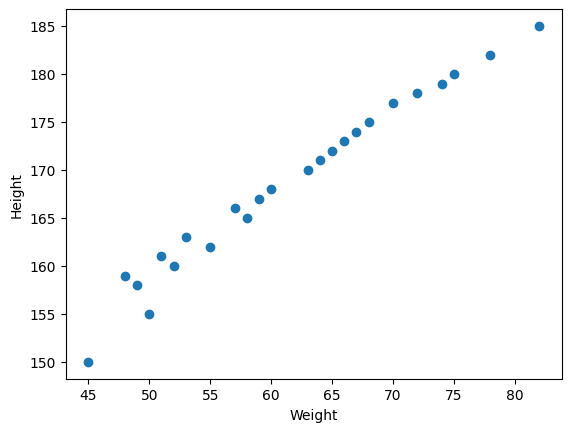

In [6]:
###scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [7]:
#Correlation
df.corr()

,Weight,Height
Weight,1.00000,0.98671
Height,0.98671,1.00000


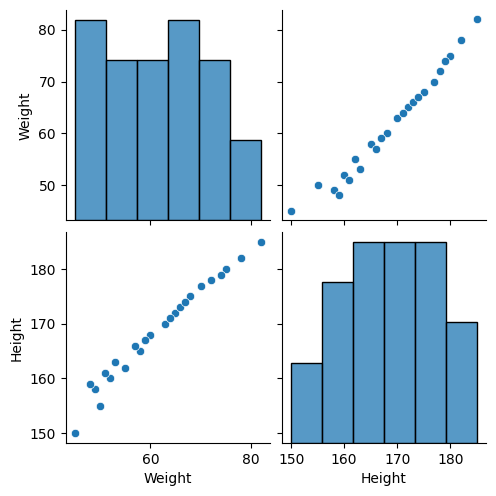

In [8]:
#Seaborn for visualisation
import seaborn as sns
sns.pairplot(df)

In [ ]:
#Independent and dependent fts
X = df[['Weight']] #independent feature should be 2 dimension array or a data frame.
Y = df['Height'] #this variable can b in series or 1d array

In [17]:
X_series = df['Weight']
np.array(X_series).shape

(24,)

In [18]:
np.array(Y).shape

(24,)

In [20]:
#Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [22]:
#Standardidsation
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [25]:
X_test = scaler.transform(X_test)

In [26]:
X_test

array([[ 0.65802871],
       [ 1.76499288],
       [-1.8879889 ],
       [-1.55589965],
       [-1.00241756],
       [ 1.10081438]])

In [27]:
##Apply linear regression
from sklearn.linear_model import LinearRegression

In [28]:
regression = LinearRegression()

In [29]:
regression.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
print("Coefficient or slope: ", regression.coef_)
print("Intercept: ", regression.intercept_)

Coefficient or slope:  [7.86525381]
Intercept:  169.05555555555554


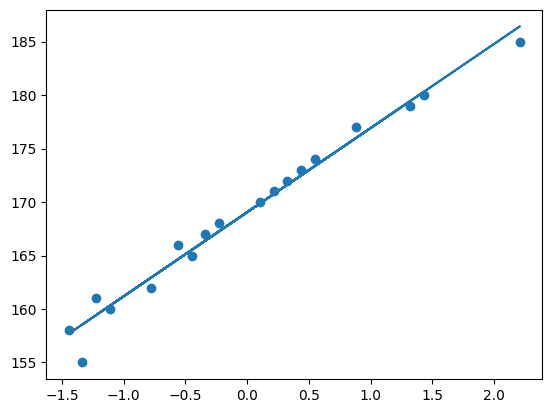

In [31]:
## plot training data plot best fir line
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))

### prediction of test data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 169.055 + 7.86(X_test)

In [37]:
## prediction for test data
y_pred = regression.predict(X_test)

In [34]:
## PErformance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [38]:
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4.558071445491891
1.701593484865678
2.1349640384540183


## R Square
Formula


**R^2 = 1 - SSR/SST**


#### R^2 = coefficient of determination 
#### SSR = sum of squares of residuals 
#### SST = total sum of squares

In [39]:
from sklearn.metrics import r2_score

In [40]:
score = r2_score(Y_test, y_pred)
print(score)

0.9647041144251004


**Adjusted R^2 = 1 - [(1-R2)*(n-1)/(n-k-1)]**

where:

#### R2: The R2 of the model
#### n: The number of observations
#### k: The number of predictor variables

In [41]:
#display adjusted R-squared
1 - (1-score)*(len(Y_test)-1)/(len(Y_test) - X_test.shape[1]-1)

0.9558801430313755

In [44]:
## ols linear regression
import statsmodels.api as sm

In [45]:
model = sm.OLS(Y_train, X_train).fit()

In [46]:
prediction = model.predict(X_test)
print(prediction)

[  5.17556278  13.882117   -14.84951191 -12.23754565  -7.88426854
   8.65818447]


In [47]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.002
Model:                            OLS   Adj. R-squared (uncentered):             -0.057
Method:                 Least Squares   F-statistic:                            0.03680
Date:                Wed, 01 Oct 2025   Prob (F-statistic):                       0.850
Time:                        14:59:28   Log-Likelihood:                         -117.89
No. Observations:                  18   AIC:                                      237.8
Df Residuals:                      17   BIC:                                      238.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

d:\VSCode\machine learning\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [48]:
## Prediction for new data
regression.predict(scaler.transform([[72]]))

d:\VSCode\machine learning\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([177.71374002])